Accuracy: 66.67 %


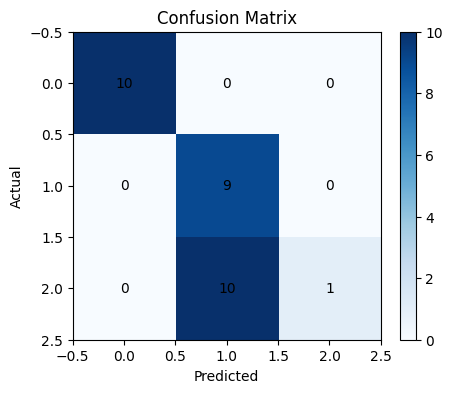

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

# Load Iris dataset
iris = load_iris()
X = iris.data[:, :2]   # Use first two features for graph
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Perceptron
model = Perceptron(max_iter=1000, eta0=0.1, random_state=42)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")

# -------------------------------
# Confusion Matrix Graph
# -------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

# -------------------------------
# Decision Boundary
# -------------------------------
X_set, y_set = X_train, y_train

X1, X2 = np.meshgrid(
    np.arange(X_set[:,0].min()-1, X_set[:,0].max()+1, 0.02),
    np.arange(X_set[:,1].min()-1, X_set[:,1].max()+1, 0.02)
)

plt.figure(figsize=(7,5))

plt.contourf(
    X1, X2,
    model.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.3,
    cmap=ListedColormap(('red','green','blue'))
)

colors = ['red','green','blue']

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set==j,0],
        X_set[y_set==j,1],
        c=colors[i],
        label=iris.target_names[j]
    )

plt.title("Perceptron Decision Boundary (Iris Dataset)")
plt.xlabel("Sepal Length (Standardized)")
plt.ylabel("Sepal Width (Standardized)")
plt.legend()
plt.show()

# -------------------------------
# Actual vs Predicted
# -------------------------------
plt.figure(figsize=(8,4))
plt.plot(y_test, 'bo-', label="Actual")
plt.plot(y_pred, 'r*-', label="Predicted")
plt.title("Actual vs Predicted Classes")
plt.xlabel("Test Samples")
plt.ylabel("Class")
plt.legend()
plt.show()